# Bloques fundamentales en arquitecturas modernas de Deep Learning 

En visión por computador, las entradas y salidas de una red convolucional suelen representarse como tensores tridimensionales:

\begin{equation}
X \in \mathbb{R}^{H \times W \times C}
\end{equation}

donde:

- $H$ = altura espacial (height)  
- $W$ = anchura espacial (width)  
- $C$ = número de canales (channels), por ejemplo RGB = 3  
- $X_{i,j,c}$ representa el valor del canal $c$ en la posición espacial $(i,j)$



## Convolución 1×1 (Pointwise Convolution)

Una convolución 1×1 aplica una transformación lineal a través de los canales, sin considerar vecindario espacial:

\begin{equation}
Y_{i,j} = W X_{i,j} + b, \quad 
W \in \mathbb{R}^{C_{\text{out}} \times C_{\text{in}}}.
\end{equation}

La salida es:

\begin{equation}
Y \in \mathbb{R}^{H \times W \times C_{\text{out}}}.
\end{equation}

No detecta patrones espaciales; solo mezcla canales.

<img src="Pointwise.png" width=800/>

---

## Depthwise Convolution

Cada canal se filtra de manera independiente, usando un kernel espacial:

\begin{equation}
W \in \mathbb{R}^{k \times k \times C_{\text{in}}}.
\end{equation}

La operación por canal es:

\begin{equation}
Y^{(c)}_{i,j}
= \sum_{u,v} W^{(c)}_{u,v}\, X^{(c)}_{i+u,\;j+v}.
\end{equation}

La salida tiene forma:

\begin{equation}
Y \in \mathbb{R}^{H \times W \times C_{\text{in}}}.
\end{equation}

No mezcla canales; solo procesa estructura espacial por canal.

<img src="Depthwise.png" width=500/>

---

## Depthwise Separable Convolution

Es la composición de:

1. **Depthwise convolution** (espacial)
2. **Pointwise convolution** (mezcla de canales)

Formalmente:

\begin{equation}
Z = W_{\text{dw}} * X
\end{equation}
\begin{equation}
Y = W_{1\times1} Z.
\end{equation}

Reduce significativamente el costo computacional:  
\begin{equation}
O(k^2 C H W) \quad \text{vs} \quad O(k^2 C^2 H W)
\end{equation}
de una conv estándar.

<img src="Depthwise_sep.png" width=600/>

---

## Convoluciones con stride (downsampling)

Una convolución con stride $s$ opera como:

\begin{equation}
Y_{i,j,c}
= \sum_{u,v,c'} W_{u,v,c',c}\, X_{i s+u,\, j s+v,\, c'}.
\end{equation}

Reduce el tamaño espacial:

\begin{equation}
H' = \left\lfloor \frac{H}{s} \right\rfloor, \quad 
W' = \left\lfloor \frac{W}{s} \right\rfloor.
\end{equation}

<img src="stride.png" width=600/>

---

## Batch Normalization (BN)

Dado un batch de tamaño $m$, para cada canal:

\begin{equation}
\mu_B = \frac{1}{mHW} \sum_{i,j,n} X_{i,j,c}^{(n)},
\quad
\sigma_B^2 = \frac{1}{mHW} \sum_{i,j,n} (X_{i,j,c}^{(n)} - \mu_B)^2.
\end{equation}

Normalización:

\begin{equation}
\hat{X}_{i,j,c}^{(n)} =
\frac{X_{i,j,c}^{(n)} - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}.
\end{equation}

Transformación aprendible:

\begin{equation}
Y_{i,j,c}^{(n)} = \gamma_c \hat{X}_{i,j,c}^{(n)} + \beta_c.
\end{equation}

---

## Layer Normalization (LN)

Para cada ejemplo, en lugar de promediar sobre el batch, se promedian los canales:

\begin{equation}
\mu = \frac{1}{C} \sum_{c} X_{i,j,c},
\quad
\sigma^2 = \frac{1}{C} \sum_c (X_{i,j,c} - \mu)^2.
\end{equation}

Normalización:

\begin{equation}
\hat{X}_{i,j,c} = \frac{X_{i,j,c}-\mu}{\sqrt{\sigma^2+\epsilon}}.
\end{equation}

Transformación:

\begin{equation}
Y_{i,j,c} = \gamma_c \hat{X}_{i,j,c} + \beta_c.
\end{equation}

LN es fundamental en Transformers.

---

<img src="normalization.png" width=600/>


## Global Average Pooling (GAP)

Colapsa cada canal a un único valor:

\begin{equation}
y_c = \frac{1}{HW} \sum_{i=1}^H \sum_{j=1}^W X_{i,j,c}.
\end{equation}

La salida es un vector:

\begin{equation}
y \in \mathbb{R}^{C}.
\end{equation}

Se interpreta como una integración espacial del mapa de características.

---

<img src="gap.png" width=600/>


## Bloques Residuales (ResNet)

Sea $F(X)$ una transformación no lineal (Conv–BN–ReLU–Conv–BN):

\begin{equation}
F(X) = \text{BN}_2 ( W_2 * \sigma(\text{BN}_1(W_1 * X)) ).
\end{equation}

El bloque residual computa:

\begin{equation}
Y = F(X) + X.
\end{equation}

En el retropropagado:

\begin{equation}
\frac{\partial L}{\partial X}
=\frac{\partial L}{\partial Y} \left( I + \frac{\partial F}{\partial X} \right),
\end{equation}

lo cual evita el *vanishing gradient*.

<img src="resnets.png" width=300/>


## Bloques Bottleneck (ResNet-50+)

Se usan tres convoluciones:

1. Reducción (1×1):
\begin{equation}
X' = W_{1} X
\end{equation}
2. Convolución espacial (3×3):
\begin{equation}
Z = W_{3\times3} * \sigma(\text{BN}(X'))
\end{equation}
3. Expansión (1×1):
\begin{equation}
F(X) = W_{2} Z
\end{equation}

Salida final:

\begin{equation}
Y = F(X) + X.
\end{equation}

La conv 3×3 opera en un espacio reducido, lo que genera menor costo computacional.

---

## Bloques Invertidos + Cuello Lineal (MobileNetV2)

1. Expansión:
\begin{equation}
E = \sigma(\text{BN}( W_{\text{exp}} X))
\end{equation}

2. Depthwise Conv:
\begin{equation}
D = \sigma(\text{BN}( W_{\text{dw}} * E))
\end{equation}

3. Proyección lineal:
\begin{equation}
P = W_{\text{proj}} D
\end{equation}

4. Residual (si procede):
\begin{equation}
Y = X + P.
\end{equation}

La linealidad en el cuello evita colapsar la representación al proyectar.

---

<img src="irb.png" width=600/>


Cada arquitectura moderna (ResNet, MobileNet, EfficientNet, ViT, CLIP) es una composición de estos operadores fundamentales.



## Transfer Learning

El **Transfer Learning** (aprendizaje por transferencia) es una técnica en la que un modelo previamente entrenado en un conjunto de datos grande y general (por ejemplo, ImageNet) se reutiliza como punto de partida para un nuevo problema. En lugar de entrenar una red neuronal desde cero -lo cual requiere grandes cantidades de datos, tiempo y capacidad de cómputo- se aprovechan los **pesos ya aprendidos** en las capas profundas del modelo.

**ImageNet** es uno de los conjuntos de datos más grandes y representativos utilizados en visión por computador. Fue creado para impulsar la investigación en reconocimiento de imágenes a gran escala y se ha convertido en un estándar para entrenar y evaluar modelos de deep learning.

- **Más de 14 millones de imágenes** recolectadas de internet.
- **Anotadas y organizadas** en más de **21.000 categorías** (sinónimos semánticos del WordNet).
- En la tarea clásica de clasificación (ImageNet-1K), se utilizan **1.000 clases** balanceadas, que incluyen animales, objetos, herramientas, vehículos, frutas, escenas, etc.
- Las imágenes son variadas en tamaño, iluminación, posición, fondo y perspectiva, lo que hace que los modelos aprendan características **robustas** y **generalizables**.

ImageNet permitió por primera vez entrenar **redes neuronales profundas** en millones de imágenes, lo que llevó a resultados revolucionarios como:

- **AlexNet (2012):** redujo drásticamente el error en la competición ImageNet.
- **VGG, GoogLeNet, ResNet, MobileNet:** arquitecturas que definieron el estado del arte.

Estos modelos se conocen como **modelos fundacionales** y son modelos de inteligencia artificial de gran escala, entrenados sobre **enormes cantidades de datos generales** y diseñados para servir como base para una amplia variedad de tareas posteriores. En lugar de especializarse en un solo problema, estos modelos aprenden **representaciones profundas y universales** que pueden reutilizarse en múltiples contextos.

En visión computacional, ejemplos típicos son:

- **ResNet** (preentrenada en ImageNet)  
- **MobileNetV2** (ligera y eficiente, ideal para transferencia)  
- **EfficientNet**, **VGG**, **Inception**, **Vision Transformers (ViT)**  

En lenguaje y multimodalidad:

- **BERT**, **GPT**, **LLaMA**, **T5**, **CLIP**, **DINO**, **SAM**  


<img src="transfer.png" width=800/>


La idea central es que:

- Las primeras capas de modelos fundacionales aprenden **características muy generales** (bordes, texturas, colores, formas básicas).
- Las capas superiores aprenden **patrones más específicos** del conjunto donde fueron entrenadas originalmente.
- Podemos **congelar** parte del modelo (para conservar sus características generales) y **entrenar sólo las últimas capas** (o añadir nuevas capas) para adaptarlo a un nuevo conjunto de datos más pequeño, como CIFAR-10.


- **Entrenamiento más rápido**  
- **Menor riesgo de sobreajuste**  
- **Mejores resultados con pocos datos**  
- **Aprovecha modelos muy potentes que ya están preentrenados**


En este notebook utilizamos *MobileNetV2 preentrenada en ImageNet* como extractor de características, y luego entrenamos un clasificador propio sobre nuestro dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
#Usaremos un conjunto de datos llamado  CIFAR10 que contiene 60,000 imágenes en color en 10 clases. 
#50.000 se usan para entrenar y 10.000 para probar
(train_images, train_labels), (test_images, test_labels)=tf.keras.datasets.cifar10.load_data()

#Pasamos a float 32 (4 bytes por pixel)
train_images = train_images.astype("float32") 
test_images = test_images.astype("float32")

2026-05-21 22:37:17.221769: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779421037.234633   17327 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779421037.238532   17327 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-21 22:37:17.251525: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


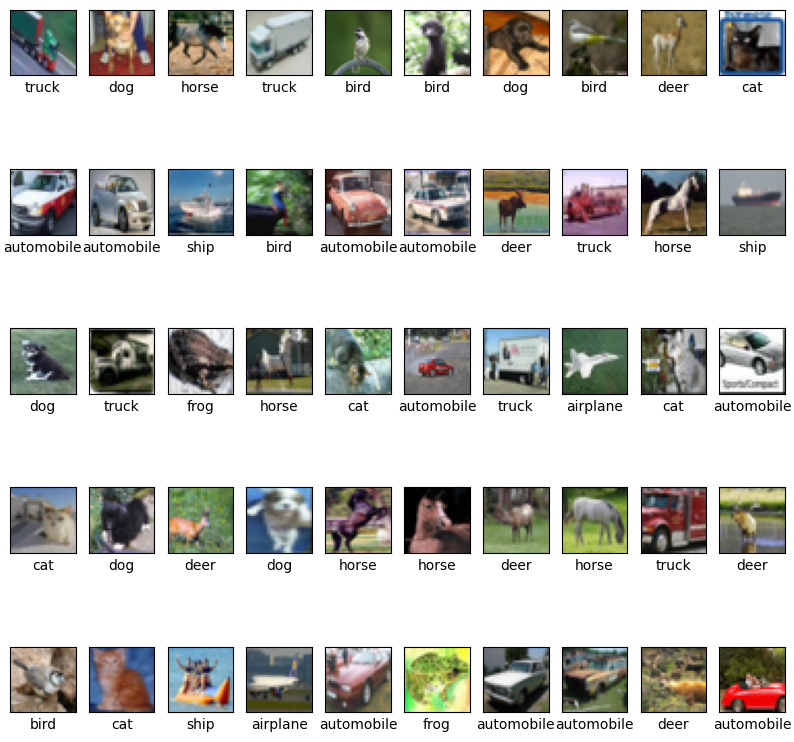

In [2]:
#Veamos algunos ejemplos
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

#Las figuras originales son de 32 X 32 pero las voy a mostrar en 10 X 10
plt.figure(figsize=(10,10))
for i in range(50,100):
    plt.subplot(5,10,i+1-50)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i]/255, cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

Ahora definiremos la arquitectura de la red:
1. Primero se definirá una función de preprocesamiento para redimiensionas las imágenes.
2. Tomamos el modelo base que va a ser MobileNetV2 y le quitamos las últimas capas (clasificación)
Vamos a aumentar los datos, introduciendo *flips* horizontales aleatorios y rotaciones del 10%.
2. Nuestros objetos de entrada ahora son tensores de tamaño 96 X 96 X 3 (R,G,B), de manera que la capa de entrada debe tener estas dimensiones. 
3. Pondremos una capa densa de 256 neuronas ReLu, seguida de una capa de dropout.
4. Finamente ponemos la capa de salida de 10 neuronas softmax.

In [3]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

#Se define una función para redimensionar y preprocesar para MobileNetV2 (espera imágenes más grandes)
IMG_SIZE = 96 
BATCH_SIZE = 128
def preprocess(image, label):
    # Redimensionar imagen
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    # Preprocesar para MobileNetV2 (pasa a rango [-1, 1])
    image = preprocess_input(image)
    return image, label

#Se crean los datasets para luego aplicarles el preprocesamiento por lotes
#Esto se hace porque la RTX 2060 tiene sólo 4GB de RAM. 50000 * 96 * 96 * 3 * 4 bytes = 5.1498 GB

train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
test_ds  = tf.data.Dataset.from_tensor_slices((test_images,  test_labels))

train_ds = (train_ds
            .shuffle(50000)
            .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

test_ds = (test_ds
           .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
           .batch(BATCH_SIZE)
           .prefetch(tf.data.AUTOTUNE))

#Definimos el modelo base para hacer transfer learning
base_model = MobileNetV2(
    include_top=False,           # quitamos la cabecera de clasificación de ImageNet
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg"                # nos da un vector 1D por imagen
)
base_model.trainable = False     # Fase 1: congelamos el modelo preentrenado

#Arquitectura de la red--------------------------------------------------------------------------------------------

modelo = models.Sequential()
# Capa de entrada (ahora de 96x96x3)
modelo.add(layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)))

# Data augmentation
modelo.add(layers.RandomFlip("horizontal"))
modelo.add(layers.RandomRotation(0.1))

# Modelo fundacional preentrenado
modelo.add(base_model)

# Capas densas de clasificación
modelo.add(layers.Dense(256, activation='relu'))
modelo.add(layers.Dropout(0.5))
modelo.add(layers.Dense(10, activation='softmax'))

#Veamos el resumen de la red hasta el momento:
modelo.summary()

I0000 00:00:1779421046.370193   17327 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4596 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 96, 96, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Ahora entrenamos el modelo:

In [4]:
modelo.compile(optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'])

llamada = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,              # si en 2 épocas no mejora, termina
    restore_best_weights=True
)

#Entrenar el modelo
history_ft = modelo.fit(
    train_ds,
    epochs=100,
    validation_data=test_ds,
    callbacks=[llamada]
)

test_loss, test_acc = modelo.evaluate(test_ds, verbose=2)
print("Test accuracy (transfer learning):", test_acc)

Epoch 1/100


I0000 00:00:1779421055.690591   17398 cuda_dnn.cc:529] Loaded cuDNN version 92200


391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.6748 - loss: 0.9488 - val_accuracy: 0.8245 - val_loss: 0.5188
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.7421 - loss: 0.7483 - val_accuracy: 0.8421 - val_loss: 0.4631
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.7583 - loss: 0.7026 - val_accuracy: 0.8432 - val_loss: 0.4554
Epoch 4/100
223/391 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.7580 - loss: 0.6858

KeyboardInterrupt: 

In [ ]:
plt.plot(history_ft.history['accuracy'])
plt.plot(history_ft.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

**MobileNetV2** es una arquitectura de red convolucional diseñada para ser ligera y eficiente:

- ≈ **155 capas** en total (dependiendo de cómo las cuente Keras).
- **17 bloques invertidos con cuellos de botella lineales**.
- Uso intensivo de **Depthwise Convolution** para maximizar eficiencia.
- Activación predominante: **ReLU6**.
- Salida final (sin top): **vector de 1280 características** tras Global Average Pooling.
- Diseñada para bajo costo computacional con excelente relación precisión/eficiencia.

Ahora vamos a hacer sintonización fina de las últimas capas del modelo. Es importante mantener una tasa de aprendizaje muy pequeña (1e-5 o incluso 5e-6) para no destrozar los pesos preentrenados.

In [ ]:
#Descongelar parcialmente MobileNetV2
base_model.trainable = True

# Congelar las capas “bajas” y entrenar solo las más profundas
fine_tune_at = 150 
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Congelar BatchNorm para estabilidad
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

#Veamos el resumen de la red hasta el momento:
modelo.summary()
        
#Recompilar con un learning rate MUCHO más pequeño
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

llamada = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,              # si en 2 épocas no mejora, termina
    restore_best_weights=True
)

#Entrenar nuevamente
history_ft = modelo.fit(
    train_ds,
    epochs=100,
    validation_data=test_ds,
    callbacks=[llamada]
)

test_loss, test_acc = modelo.evaluate(test_ds, verbose=2)
print("Test accuracy (transfer learning):", test_acc)